# Notebook 03: Emissions & Intensity

**One Sensor, One Year — Edition 2: US Grid**

How much CO₂ does the US power grid emit every day of 2025, and how clean is each MWh it delivers?

**Approach:**
- Apply EPA eGRID 2023 national fuel factors to each EIA-930 fuel code
- Compute daily CO₂ per fuel → daily total → emissions intensity (tCO₂/MWh) for **US48**
- Compute the same for each of the **top-10 BAs** so we can rank them
- Find the cleanest and dirtiest days of US48 2025 and identify what drove them
- Compare against **Texas (ERCOT) 2025** (Ed2 detail lens) and **India 2024** (Ed1)

**Key caveat:** EIA-930 lumps gas-CC and simple-cycle peakers into one `NG` code, so we can't do the CC/simple split that Texas notebook 03 does. We use a single national-weighted gas factor (~0.40 tCO₂/MWh) that reflects the US fleet's ~80% CC mix. This loses some intra-BA texture (CC-heavy CISO emits less per gas-MWh than peaker-heavy CAISO summer days) but is consistent and defensible.

**Inputs:** `../data/processed/us48_2025_daily.csv`, `../data/processed/ba_2025_hourly.parquet`

**Outputs:** `../data/processed/us48_2025_derived.csv`, `../data/processed/emission_factors_us.json`, `../data/processed/ba_2025_intensity.csv`

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
YEAR = 2025

us48_daily = pd.read_csv(PROCESSED / f'us48_{YEAR}_daily.csv', parse_dates=['date'], index_col='date')
ba_long = pd.read_parquet(PROCESSED / f'ba_{YEAR}_hourly.parquet')
print(f'US48 daily: {us48_daily.shape}')
print(f'BA long:    {ba_long.shape} ({ba_long["respondent"].nunique()} BAs)')

FUEL_COLORS = {
    'COL': '#D4890E', 'NG': '#F0C078', 'NUC': '#2A9D8F', 'WND': '#72B352',
    'SUN': '#F4C430', 'WAT': '#264653', 'OTH': '#9B72CF', 'BAT': '#A0A0A0',
    'UES': '#C0C0C0', 'OES': '#B8B8B8', 'PS':  '#7090A8', 'OIL': '#5A3825',
    'GEO': '#A0524D', 'SNB': '#FFE066', 'WNB': '#9DC183', 'UNK': '#777777',
}
FUEL_LABELS = {
    'COL': 'Coal', 'NG': 'Natural Gas', 'NUC': 'Nuclear', 'WND': 'Wind',
    'SUN': 'Solar', 'WAT': 'Hydro', 'OTH': 'Other', 'BAT': 'Battery',
    'OIL': 'Oil', 'GEO': 'Geothermal',
}

US48 daily: (365, 16)
BA long:    (808277, 4) (10 BAs)


## 1. Emission factors

Units: **tonnes CO₂ per MWh of generation** (= kg per kWh).

| Fuel | Factor (tCO₂/MWh) | Source |
|---|---|---|
| COL — Coal | 0.95 | EPA eGRID 2023 national bituminous/sub-bituminous fleet (~2,100 lb/MWh ÷ 2,205) |
| NG — Natural Gas | 0.40 | EPA eGRID 2023 national all-class (CC + simple weighted, US is ~80% CC) |
| OIL — Petroleum | 0.78 | EPA national petroleum / fuel-oil class |
| OTH — Other | 0.50 | Conservative estimate; OTH = biomass + landfill + waste mixture |
| NUC, WAT, WND, SUN, GEO | 0.00 | Zero direct combustion emissions |
| SNB, WNB | 0.00 | Sub-categories of solar/wind — clean |
| BAT, PS, OES, UES | n/a | Storage — net flow, not generation; excluded |
| UNK | 0.00 | Trace; treat as clean (negligible volume) |

**Caveats:**
1. *Direct combustion* emissions only — not lifecycle (extraction, transport, construction).
2. EIA-930 doesn't split CC vs simple-cycle gas — the 0.40 factor is a national average. Per-BA accuracy would benefit from eGRID subregion factors (future work).
3. India comparison uses generic IPCC factors (Ed1 method); the same caveat as Texas N03 applies.

In [2]:
# tCO2 / MWh per fuel
EMISSION_FACTORS = {
    'COL': 0.95,
    'NG':  0.40,
    'OIL': 0.78,
    'OTH': 0.50,
    'NUC': 0.00,
    'WAT': 0.00,
    'WND': 0.00,
    'SUN': 0.00,
    'GEO': 0.00,
    'SNB': 0.00,
    'WNB': 0.00,
    'UNK': 0.00,
}
STORAGE_CODES = {'BAT', 'PS', 'OES', 'UES'}
EMITTING_FUELS = [f for f, v in EMISSION_FACTORS.items() if v > 0]
GEN_COLS = [c for c in us48_daily.columns if c not in STORAGE_CODES]

factor_meta = {
    'units': 'tonnes CO2 per MWh of generation',
    'scope': 'direct combustion emissions, not lifecycle',
    'source': {
        'COL': 'EPA eGRID 2023 national coal fleet',
        'NG':  'EPA eGRID 2023 national gas (CC + simple-cycle weighted, ~80% CC)',
        'OIL': 'EPA petroleum / fuel-oil factor',
        'OTH': 'Conservative weighted estimate for biomass + landfill + waste mix',
        'clean': 'Zero direct emissions for NUC, WAT, WND, SUN, GEO, SNB, WNB',
    },
    'notes': [
        'EIA-930 lumps combined-cycle and simple-cycle gas as one NG bucket; we cannot split.',
        'Per-BA accuracy could be improved by using eGRID subregion-specific factors instead of national.',
    ],
}
print(f'Emitting fuels: {EMITTING_FUELS}')
print(f'Generation cols: {GEN_COLS}')

Emitting fuels: ['COL', 'NG', 'OIL', 'OTH']
Generation cols: ['COL', 'GEO', 'NG', 'NUC', 'OIL', 'OTH', 'SNB', 'SUN', 'UNK', 'WAT', 'WNB', 'WND']


## 2. Compute daily CO₂ and intensity for US48

In [3]:
for fuel, factor in EMISSION_FACTORS.items():
    if fuel in us48_daily.columns:
        us48_daily[f'co2_{fuel}'] = us48_daily[fuel] * factor

co2_cols = [f'co2_{f}' for f in EMITTING_FUELS if f in us48_daily.columns]
us48_daily['co2_total'] = us48_daily[co2_cols].sum(axis=1)
us48_daily['intensity'] = us48_daily['co2_total'] / us48_daily[GEN_COLS].sum(axis=1)

annual_co2_mt = us48_daily['co2_total'].sum() / 1e6
annual_gen_twh = us48_daily[GEN_COLS].sum().sum() / 1e6
mean_intensity = us48_daily['intensity'].mean()

print(f'US48 {YEAR} — CO₂ Emissions Summary')
print('=' * 50)
print(f'Annual CO₂:        {annual_co2_mt:>8,.0f} Mt')
print(f'Annual generation: {annual_gen_twh:>8,.0f} TWh')
print(f'Mean daily CO₂:    {us48_daily["co2_total"].mean()/1e3:>8,.0f} kt/day')
print(f'Mean intensity:    {mean_intensity:>8.3f} tCO₂/MWh')
print()
print('Per-fuel annual CO₂ (Mt):')
for f in EMITTING_FUELS:
    if f in us48_daily.columns:
        mt = us48_daily[f'co2_{f}'].sum() / 1e6
        share = mt / annual_co2_mt * 100
        print(f'  {FUEL_LABELS.get(f, f):14s}: {mt:6,.0f} Mt  ({share:4.1f}%)')

US48 2025 — CO₂ Emissions Summary
Annual CO₂:           1,420 Mt
Annual generation:    4,269 TWh
Mean daily CO₂:       3,890 kt/day
Mean intensity:       0.330 tCO₂/MWh

Per-fuel annual CO₂ (Mt):
  Coal          :    714 Mt  (50.3%)
  Natural Gas   :    675 Mt  (47.5%)
  Oil           :      6 Mt  ( 0.4%)
  Other         :     24 Mt  ( 1.7%)


## 3. Intensity time series

Daily values + 7-day rolling average. Reference bands for Texas (ERCOT 2025) and India (Ed1 2024) for context.

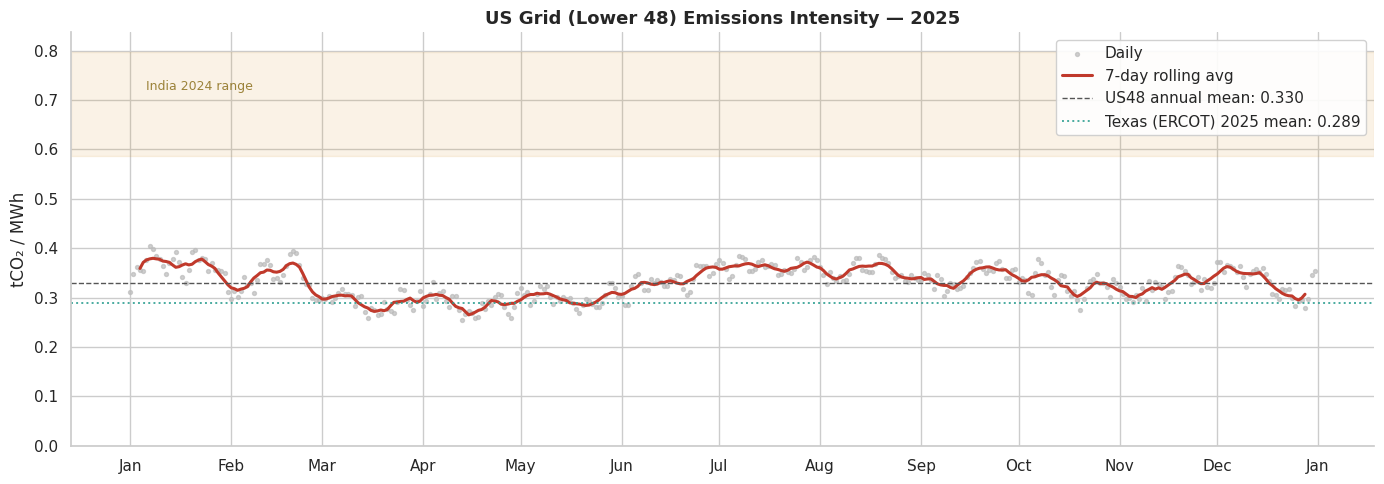

In [4]:
# References
TX_MEAN = 0.2895   # from texas_2025_stats.json (we'll re-derive in cell 6)
INDIA_MEAN, INDIA_MIN, INDIA_MAX = 0.721, 0.587, 0.797  # tCO2/MWh, Ed1 N03

intensity = us48_daily['intensity']
smooth = intensity.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(intensity.index, intensity.values, s=8, color='#BBBBBB', alpha=0.7, label='Daily')
ax.plot(smooth.index, smooth.values, color='#C0392B', linewidth=2.2, label='7-day rolling avg')
ax.axhline(intensity.mean(), color='#555', linestyle='--', linewidth=1,
           label=f'US48 annual mean: {intensity.mean():.3f}')

ax.axhspan(INDIA_MIN, INDIA_MAX, color='#D4890E', alpha=0.10)
ax.text(intensity.index[5], INDIA_MEAN, 'India 2024 range',
        fontsize=9, color='#8B6F1B', alpha=0.85)
ax.axhline(TX_MEAN, color='#2A9D8F', linestyle=':', linewidth=1.4, alpha=0.85,
           label=f'Texas (ERCOT) 2025 mean: {TX_MEAN:.3f}')

ax.set_ylabel('tCO₂ / MWh')
ax.set_title(f'US Grid (Lower 48) Emissions Intensity — {YEAR}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylim(0, max(INDIA_MAX, intensity.max()) * 1.05)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / f'us48_{YEAR}_intensity.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Daily CO₂ stacked by source

Who is emitting and how the mix shifts through the year.

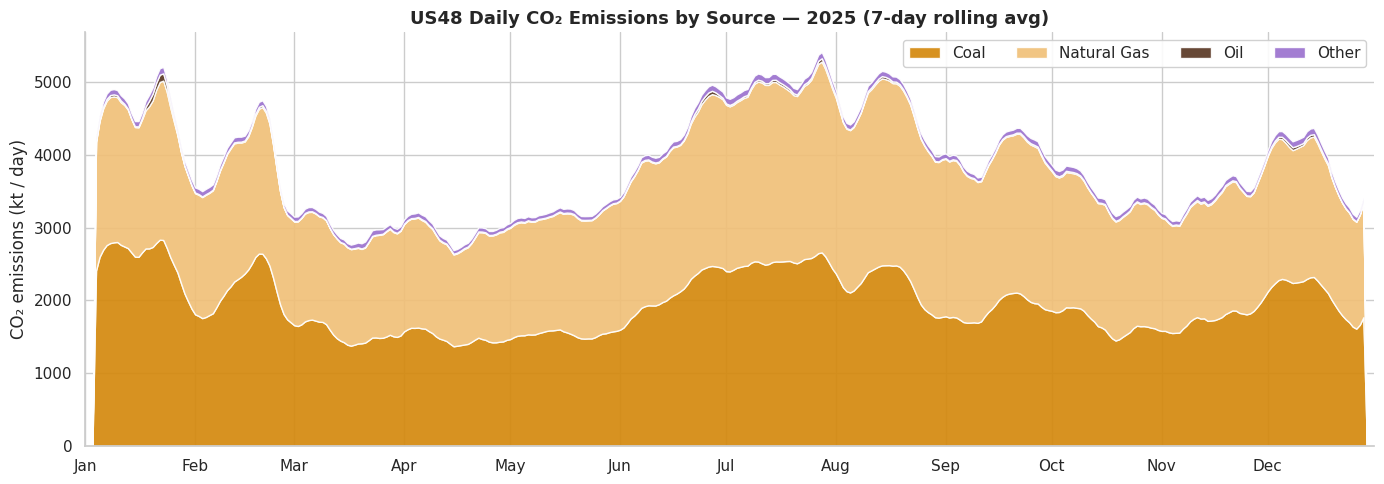

In [5]:
stack_cols = [c for c in [f'co2_{f}' for f in EMITTING_FUELS] if c in us48_daily.columns]
stack_labels = [FUEL_LABELS.get(c.replace('co2_', ''), c) for c in stack_cols]
stack_colors = [FUEL_COLORS.get(c.replace('co2_', ''), '#888') for c in stack_cols]

plot_data = us48_daily[stack_cols].rolling(7, center=True).mean() / 1e3  # kt/day

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(plot_data.index,
             *[plot_data[c].fillna(0) for c in stack_cols],
             labels=stack_labels,
             colors=stack_colors,
             alpha=0.92)
ax.set_ylabel('CO₂ emissions (kt / day)')
ax.set_title(f'US48 Daily CO₂ Emissions by Source — {YEAR} (7-day rolling avg)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', ncol=4, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(plot_data.index.min(), plot_data.index.max())
sns.despine()
plt.tight_layout()
plt.show()

## 5. The cleanest and dirtiest days

What drove the extremes? Print the fuel mix so the reason is visible.

In [6]:
def describe_day(date):
    row = us48_daily.loc[date]
    total_gen = row[GEN_COLS].sum()
    print(f'  {date.strftime("%A, %B %d, %Y")}')
    print(f'  Intensity: {row["intensity"]:.3f} tCO₂/MWh')
    print(f'  Total gen: {total_gen/1e3:,.0f} GWh')
    print(f'  CO₂:       {row["co2_total"]/1e3:,.0f} kt')
    print(f'  Mix:')
    for fuel in ['COL', 'NG', 'NUC', 'WND', 'SUN', 'WAT', 'OTH', 'OIL', 'GEO']:
        if fuel in us48_daily.columns:
            val = row[fuel]
            if val > 0:
                pct = val / total_gen * 100
                print(f'    {FUEL_LABELS.get(fuel, fuel):14s}: {val/1e3:7.1f} GWh  ({pct:5.1f}%)')

cleanest = us48_daily['intensity'].idxmin()
dirtiest = us48_daily['intensity'].idxmax()

print('CLEANEST DAY:')
describe_day(cleanest)
print()
print('DIRTIEST DAY:')
describe_day(dirtiest)

CLEANEST DAY:
  Sunday, April 13, 2025
  Intensity: 0.254 tCO₂/MWh
  Total gen: 9,732 GWh
  CO₂:       2,477 kt
  Mix:
    Coal          :  1353.8 GWh  ( 13.9%)
    Natural Gas   :  2840.0 GWh  ( 29.2%)
    Nuclear       :  1938.1 GWh  ( 19.9%)
    Wind          :  1831.9 GWh  ( 18.8%)
    Solar         :   838.8 GWh  (  8.6%)
    Hydro         :   800.1 GWh  (  8.2%)
    Other         :    98.6 GWh  (  1.0%)
    Oil           :     6.7 GWh  (  0.1%)
    Geothermal    :    11.7 GWh  (  0.1%)

DIRTIEST DAY:
  Tuesday, January 07, 2025
  Intensity: 0.404 tCO₂/MWh
  Total gen: 13,198 GWh
  CO₂:       5,336 kt
  Mix:
    Coal          :  3203.0 GWh  ( 24.3%)
    Natural Gas   :  5476.0 GWh  ( 41.5%)
    Nuclear       :  2348.8 GWh  ( 17.8%)
    Wind          :   754.5 GWh  (  5.7%)
    Solar         :   459.9 GWh  (  3.5%)
    Hydro         :   756.0 GWh  (  5.7%)
    Other         :   147.4 GWh  (  1.1%)
    Oil           :    37.0 GWh  (  0.3%)
    Geothermal    :    11.2 GWh  (  0.1%)


## 6. Per-BA emissions intensity

How dirty/clean is each of the top-10 BAs? This is the regional-contrast headline — same data lens, very different fleet compositions.

Annual emissions intensity (2025)
      gen_TWh  co2_Mt  intensity
US48   4268.7  1419.8      0.330
BPAT     82.3     3.0      0.036
CISO    186.3    31.0      0.166
NYIS    132.4    29.7      0.224
ISNE    105.0    27.6      0.263
ERCO    488.0   140.1      0.287
TVA     162.7    48.7      0.299
PJM     873.5   295.6      0.338
SOCO    252.3    93.0      0.369
SWPP    302.5   113.9      0.376
MISO    659.2   277.6      0.421


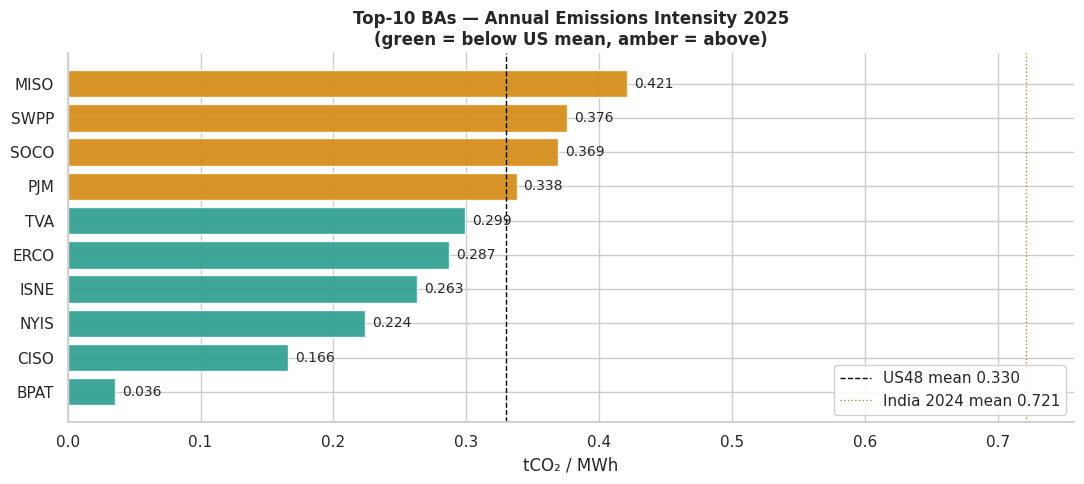

In [7]:
# Annual per-BA: total generation, total CO2, intensity
ba_annual = (ba_long
    .groupby(['respondent', 'fueltype'])['value_mwh']
    .sum()
    .unstack(fill_value=0))

ba_annual['gen_mwh'] = ba_annual[[c for c in ba_annual.columns if c not in STORAGE_CODES]].sum(axis=1)
ba_annual['co2_t'] = sum(
    ba_annual.get(f, pd.Series(0, index=ba_annual.index)) * EMISSION_FACTORS[f]
    for f in EMITTING_FUELS if f in ba_annual.columns
)
ba_annual['intensity'] = ba_annual['co2_t'] / ba_annual['gen_mwh']

# Add Texas (ERCOT XLSX-derived) and India (Ed1) for the comparison plot
ba_view = ba_annual[['gen_mwh', 'co2_t', 'intensity']].copy()
ba_view['gen_TWh'] = (ba_view['gen_mwh'] / 1e6).round(1)
ba_view['co2_Mt'] = (ba_view['co2_t'] / 1e6).round(1)
ba_view['intensity'] = ba_view['intensity'].round(3)
ba_view = ba_view[['gen_TWh', 'co2_Mt', 'intensity']].sort_values('intensity')

us48_row = pd.DataFrame({
    'gen_TWh': [round(annual_gen_twh, 1)],
    'co2_Mt': [round(annual_co2_mt, 1)],
    'intensity': [round(mean_intensity, 3)],
}, index=['US48'])
ba_view = pd.concat([us48_row, ba_view])

print(f'Annual emissions intensity ({YEAR})')
print('=' * 65)
print(ba_view.to_string())

# Save BA intensity table
ba_view.to_csv(PROCESSED / f'ba_{YEAR}_intensity.csv')

# Sorted bar chart
fig, ax = plt.subplots(figsize=(11, 5))
to_plot = ba_view.drop('US48').sort_values('intensity')
colors_ = ['#2A9D8F' if v < mean_intensity else '#D4890E' for v in to_plot['intensity']]
bars = ax.barh(to_plot.index, to_plot['intensity'], color=colors_, alpha=0.9)
for bar, val in zip(bars, to_plot['intensity']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
ax.axvline(mean_intensity, color='black', linestyle='--', linewidth=1, label=f'US48 mean {mean_intensity:.3f}')
ax.axvline(INDIA_MEAN, color='#8B6F1B', linestyle=':', linewidth=1, alpha=0.8, label=f'India 2024 mean {INDIA_MEAN:.3f}')
ax.set_xlabel('tCO₂ / MWh')
ax.set_title(f'Top-10 BAs — Annual Emissions Intensity {YEAR}\n(green = below US mean, amber = above)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / f'ba_{YEAR}_intensity_bar.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. US vs Texas vs India side-by-side

**Caveat (same as Texas N03):** Ed1 India used generic IPCC-style factors (coal 0.95, lignite 1.10, gas 0.40). Ed2 US uses EPA eGRID national factors. Texas N03 uses eGRID-ERCT subregion factors plus an NETL CC/simple split. The three are not strictly like-for-like — but the *order of magnitude* and the relative ranking are robust.

In [8]:
tx_stats = json.loads((Path('../../texas-grid/data/processed/texas_2025_stats.json')).read_text())
tx_co2 = json.loads((Path('../../texas-grid/data/processed/emission_factors_egrid.json')).read_text())
TX_GEN = tx_stats['total_annual_twh']
TX_CO2 = tx_co2['annual_summary_2025']['total_co2_mt']
TX_INT = tx_co2['annual_summary_2025']['mean_intensity_tco2_per_mwh']

# India 2024 from Ed1 (TWh and Mt are approximate; intensity is the canonical Ed1 number)
INDIA_GEN = 1700
INDIA_CO2 = INDIA_GEN * INDIA_MEAN   # ≈ 1226 Mt

compare = pd.DataFrame({
    'Generation (TWh)': [annual_gen_twh, TX_GEN, INDIA_GEN],
    'CO₂ (Mt)': [annual_co2_mt, TX_CO2, INDIA_CO2],
    'Intensity (tCO₂/MWh)': [mean_intensity, TX_INT, INDIA_MEAN],
    'Cleanest day': [intensity.min(), tx_co2['annual_summary_2025']['cleanest_intensity'], INDIA_MIN],
    'Dirtiest day': [intensity.max(), tx_co2['annual_summary_2025']['dirtiest_intensity'], INDIA_MAX],
}, index=['US48 2025', 'Texas (ERCOT) 2025', 'India 2024'])

print('Cross-edition comparison')
print('=' * 90)
print(compare.round(3).to_string())
print()
print(f'Texas mean is {(1 - TX_INT/mean_intensity)*100:.0f}% lower than US48 mean.')
print(f'US48 mean is {(1 - mean_intensity/INDIA_MEAN)*100:.0f}% lower than India mean.')
print(f'US emits ~{annual_co2_mt:,.0f} Mt CO₂ from electricity vs India ~{INDIA_CO2:,.0f} Mt — comparable magnitude despite 2.5× more generation.')

Cross-edition comparison
                    Generation (TWh)  CO₂ (Mt)  Intensity (tCO₂/MWh)  Cleanest day  Dirtiest day
US48 2025                   4268.745  1419.772                 0.330         0.254         0.404
Texas (ERCOT) 2025           494.800   144.700                 0.290         0.148         0.433
India 2024                  1700.000  1225.700                 0.721         0.587         0.797

Texas mean is 12% lower than US48 mean.
US48 mean is 54% lower than India mean.
US emits ~1,420 Mt CO₂ from electricity vs India ~1,226 Mt — comparable magnitude despite 2.5× more generation.


## 8. Save outputs

- `us48_2025_derived.csv` — daily table with per-fuel CO₂ columns and intensity
- `emission_factors_us.json` — factors + provenance
- `ba_2025_intensity.csv` — already saved in cell 6

In [9]:
derived_path = PROCESSED / f'us48_{YEAR}_derived.csv'
us48_daily.to_csv(derived_path)
new_cols = [c for c in us48_daily.columns if c.startswith('co2_') or c == 'intensity']
print(f'Saved {derived_path.name} ({len(us48_daily)} × {us48_daily.shape[1]} cols)')
print(f'  New columns: {new_cols}')

factors_out = {
    'factors': EMISSION_FACTORS,
    'metadata': factor_meta,
    'annual_summary_2025': {
        'total_co2_mt': round(float(annual_co2_mt), 1),
        'total_gen_twh': round(float(annual_gen_twh), 1),
        'mean_intensity_tco2_per_mwh': round(float(mean_intensity), 4),
        'cleanest_day': cleanest.strftime('%Y-%m-%d'),
        'cleanest_intensity': round(float(intensity.min()), 4),
        'dirtiest_day': dirtiest.strftime('%Y-%m-%d'),
        'dirtiest_intensity': round(float(intensity.max()), 4),
    },
}
factors_path = PROCESSED / 'emission_factors_us.json'
with open(factors_path, 'w') as f:
    json.dump(factors_out, f, indent=2)
print(f'Saved {factors_path.name}')

Saved us48_2025_derived.csv (365 × 30 cols)
  New columns: ['co2_COL', 'co2_NG', 'co2_OIL', 'co2_OTH', 'co2_NUC', 'co2_WAT', 'co2_WND', 'co2_SUN', 'co2_GEO', 'co2_SNB', 'co2_WNB', 'co2_UNK', 'co2_total', 'intensity']
Saved emission_factors_us.json
